# A/B Experiment Evaluation

Read the microservice log (`service/ab_logs/predictions_log.csv`) and check:

- how many requests went to variant A and to variant B,
- the mean predicted probabilities,
- if the log contains `Y`, ROC-AUC and Average Precision for both models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

LOG_PATH = "../service/ab_logs/predictions_log.csv"
log_df = pd.read_csv(LOG_PATH)
print(f"Log shape: {log_df.shape}")
log_df.head()

Log shape: (71, 14)


,timestamp,request_id,user_id,listing_id,model_variant,model_name,booking_probability,days_since_last_review,alltime_review_count,reviews_in_last_90_days,price,property_type,room_type,Y
0,2026-06-06T15:19:43.296844+00:00,dc05f795-1f38-42a9-9bb0-374ac35d3641,40137464,955594135974379648,B,RandomForest,0.333544,-1.0,0,0,1200.0,Unknown,Unknown,0.0
1,2026-06-06T15:19:48.852967+00:00,3abfa9d3-9b58-45af-86d6-81110e2e491b,40137464,955594135974379648,B,RandomForest,0.333544,-1.0,0,0,1200.0,Unknown,Unknown,NaN
2,2026-06-06T15:19:48.862597+00:00,5b0c9728-aae7-4b04-9c6b-2fd2d90dc269,360554333,1244147958257977344,A,LogisticRegression,0.331689,-1.0,0,0,1035.0,Unknown,Entire home/apt,NaN
3,2026-06-06T15:19:48.871745+00:00,ad928709-2e0f-48ee-b851-d90a69505906,179697571,1397753249851294464,A,LogisticRegression,0.883403,5.0,2,2,1200.0,Private room in condo,Private room,NaN
4,2026-06-06T15:19:48.880648+00:00,658cc5e1-4ee5-404e-a510-27fa38a6ac65,360554333,1502922937698947584,A,LogisticRegression,0.356000,-1.0,0,0,2143.0,Entire rental unit,Entire home/apt,NaN


## Requests per variant

In [2]:
variant_counts = log_df['model_variant'].value_counts().sort_index()
print(variant_counts)
print(f"\nUdział A: {variant_counts.get('A', 0) / len(log_df):.1%}")
print(f"Udział B: {variant_counts.get('B', 0) / len(log_df):.1%}")

model_variant
A    34
B    37
Name: count, dtype: int64

Udział A: 47.9%
Udział B: 52.1%


## Mean predicted probabilities

In [3]:
summary = log_df.groupby('model_variant')['booking_probability'].agg(['count', 'mean', 'median', 'std'])
print(summary.round(4))

               count    mean  median     std
model_variant                               
A                 34  0.4523  0.3846  0.1840
B                 37  0.3606  0.3300  0.0978


## Prediction distribution

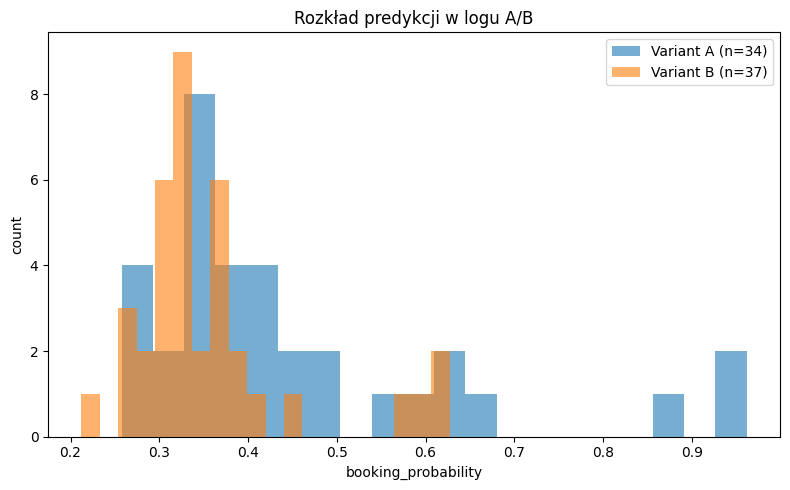

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for variant in sorted(log_df['model_variant'].unique()):
    subset = log_df.loc[log_df['model_variant'] == variant, 'booking_probability']
    ax.hist(subset, bins=20, alpha=0.6, label=f"Variant {variant} (n={len(subset)})")

ax.set_xlabel('booking_probability')
ax.set_ylabel('count')
ax.set_title('Rozkład predykcji w logu A/B')
ax.legend()
plt.tight_layout()
plt.show()

## Metrics on logged requests (when Y is present)

The `Y` field can be supplied in test requests to compare the models on historical data.

In [ ]:
labeled = log_df.dropna(subset=['Y']).copy()
labeled['Y'] = labeled['Y'].astype(int)

if labeled.empty:
    print('Brak etykiet Y w logu - pomijamy ROC-AUC i AP.')
else:
    print(f"Requesty z etykietą Y: {len(labeled)}")
    metrics = []
    for variant in sorted(labeled['model_variant'].unique()):
        subset = labeled[labeled['model_variant'] == variant]
        y_true = subset['Y']
        y_prob = subset['booking_probability']
        metrics.append({
            'model_variant': variant,
            'model_name': subset['model_name'].iloc[0],
            'n': len(subset),
            'ROC-AUC': roc_auc_score(y_true, y_prob),
            'Average Precision': average_precision_score(y_true, y_prob),
            'positive_rate': y_true.mean(),
        })
    metrics_df = pd.DataFrame(metrics)
    display(metrics_df.round(4))

Requesty z etykietą Y: 51


/home/maciek/Documents/studia/sem6/ium/projekt/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/maciek/Documents/studia/sem6/ium/projekt/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/maciek/Documents/studia/sem6/ium/projekt/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/maciek/Documents/studia/sem6/ium/projekt/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


,model_variant,model_name,n,ROC-AUC,Average Precision,positive_rate
0,A,LogisticRegression,21,NaN,0.0,0.0
1,B,RandomForest,30,NaN,0.0,0.0


## Conclusions

- the log shows whether A/B traffic is reasonably balanced (with deterministic assignment by `user_id` this depends on the distribution of users in the requests),
- mean predictions for A and B can differ, since they are different models,
- when `Y` is in the log, ROC-AUC and AP can be compared offline - a simple evaluation of the experiment on historical data.